In [79]:
# ============================
# 0. Imports
# ============================
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

import xgboost as xgb
import mlflow
import mlflow.sklearn
import shap
import matplotlib.pyplot as plt 


In [178]:
# ============================
# 1. Load data
# ============================
df = pd.read_csv("Agrofood_co2_emission_clean.csv")

# Shift so logs are valid (avoids log(0))
shift = max(1 - df["total_emission"].min(), 0)
df["log_total_emission"] = np.log(df["total_emission"] + shift)

### USING ALL FEATURES 

In [179]:
# ============================
# 2. FEATURE BUCKETS (Natural Groupings)
# ============================

land_use_features = [
    "Savanna fires",
    "Forest fires",
    "Forestland",
    "Net Forest conversion",
    "Drained organic soils (CO2)",
    "Fires in organic soils",
    "Fires in humid tropical forests",
]

agriculture_livestock_features = [
    "Crop Residues",
    "Rice Cultivation",
    "Manure applied to Soils",
    "Manure left on Pasture",
    "Manure Management",
    "Fertilizers Manufacturing",
    "IPPU",
]

energy_use_features = [
    "On-farm Electricity Use",
    "Food Processing",
    "Food Packaging",
    "Food Transport",
    "Food Retail",
    "Food Household Consumption",
    "Agrifood Systems Waste Disposal",
    "On-farm energy use",
    "Pesticides Manufacturing",
]

population_features = [
    "Rural population",
    "Urban population",
    "Total Population - Male",
    "Total Population - Female",
]

# temperature_features = [
#     "Average Temperature °C",
# ]

categorical_features = ["Area"]
time_features = ["Year"]


In [180]:
# ============================
# 3. Define features and target
# ============================

all_features = (
    land_use_features
    + agriculture_livestock_features
    + energy_use_features
    + population_features
    + categorical_features
    + time_features
)

X = df[all_features]
y = df["log_total_emission"]

In [181]:
TRAIN_END_YEAR = 2014

train_mask = df["Year"] <= TRAIN_END_YEAR
test_mask  = df["Year"] > TRAIN_END_YEAR

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(X_train.shape, X_test.shape)

# ============================
# Save train/test splits to CSV for reuse
# ============================

train_df = df.loc[train_mask].copy()
test_df  = df.loc[test_mask].copy()

train_df.to_csv("agro_co2_train.csv", index=False)
test_df.to_csv("agro_co2_test.csv", index=False)

print("Saved: agro_co2_train.csv and agro_co2_test.csv")

(5603, 29) (1362, 29)
Saved: agro_co2_train.csv and agro_co2_test.csv


In [182]:
# ============================
# 4. Preprocessor
# ============================
categorical_cols = ["Area"]
numerical_cols = [col for col in all_features if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [183]:
# ============================
# 5. Define Models and Hparam grids
# ============================
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=20000),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    )
}

param_grids = {
    "Ridge": {
        "model__alpha": [0.1, 1.0, 10],
    },

    "Lasso": {
        "model__alpha": [0.001, 0.01, 0.1],
    },

    "RandomForest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10],
        "model__min_samples_split": [2, 5],
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [4, 6],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8],
        "model__colsample_bytree": [0.8, 1.0],
    }
}


In [184]:
# ============================
# 6. Train & Evaluate Function 
# ============================
from sklearn.model_selection import GridSearchCV

def evaluate(model_name, model, X_train, X_test, y_train, y_test):
    
    # Build pipeline for THIS model
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Check if this model has a tuning grid
    if model_name in param_grids:
        print(f"🔍 Tuning {model_name}...")
        search = GridSearchCV(
            pipe,
            param_grids[model_name],
            cv=3,
            n_jobs=-1,
            scoring="neg_root_mean_squared_error"
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
    else:
        print(f"🚀 Training {model_name} (no tuning)...")
        best_model = pipe.fit(X_train, y_train)

    # Evaluate using best_model
    pred_train = best_model.predict(X_train)
    pred_test  = best_model.predict(X_test)

    rmse_train = mean_squared_error(y_train, pred_train, squared=False)
    rmse_test  = mean_squared_error(y_test,  pred_test, squared=False)
    r2_train   = r2_score(y_train, pred_train)
    r2_test    = r2_score(y_test,  pred_test)

    print(f"\n### {model_name} Results ###")
    print(f"Train RMSE: {rmse_train:.3f} | R²: {r2_train:.3f}")
    print(f"Test  RMSE: {rmse_test:.3f} | R²: {r2_test:.3f}")

    return {
        "model": best_model,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_train": r2_train,
        "r2_test": r2_test
    }


In [185]:
# ============================
# 7. Train all models
# ============================
results = {}

for name, model in models.items():
    results[name] = evaluate(name, model, X_train, X_test, y_train, y_test)


🔍 Tuning Ridge...


python(88013) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(88014) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(88015) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(88016) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(88017) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(88018) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(88019) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(88020) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



### Ridge Results ###
Train RMSE: 0.158 | R²: 0.749
Test  RMSE: 0.121 | R²: 0.804
🔍 Tuning Lasso...

### Lasso Results ###
Train RMSE: 0.169 | R²: 0.712
Test  RMSE: 0.082 | R²: 0.910
🔍 Tuning RandomForest...

### RandomForest Results ###
Train RMSE: 0.057 | R²: 0.968
Test  RMSE: 0.036 | R²: 0.982
🔍 Tuning XGBoost...

### XGBoost Results ###
Train RMSE: 0.158 | R²: 0.749
Test  RMSE: 0.135 | R²: 0.757


In [186]:
for name, res in results.items():
    pipe = res["model"]                     # full pipeline
    model = pipe.named_steps["model"]       # get underlying estimator
    best_params = model.get_params()        # extract hyperparameters

    print(f"\n🔎 Best hyperparameters for {name}:")
    for p, v in best_params.items():
        print(f"  {p}: {v}")




🔎 Best hyperparameters for Ridge:
  alpha: 10
  copy_X: True
  fit_intercept: True
  max_iter: None
  normalize: deprecated
  positive: False
  random_state: None
  solver: auto
  tol: 0.001

🔎 Best hyperparameters for Lasso:
  alpha: 0.01
  copy_X: True
  fit_intercept: True
  max_iter: 20000
  normalize: deprecated
  positive: False
  precompute: False
  random_state: None
  selection: cyclic
  tol: 0.0001
  warm_start: False

🔎 Best hyperparameters for RandomForest:
  bootstrap: True
  ccp_alpha: 0.0
  criterion: squared_error
  max_depth: 10
  max_features: 1.0
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  n_estimators: 100
  n_jobs: None
  oob_score: False
  random_state: 42
  verbose: 0
  warm_start: False

🔎 Best hyperparameters for XGBoost:
  objective: reg:squarederror
  base_score: None
  booster: None
  callbacks: None
  colsample_bylevel: None
  colsample_bynode: None
 

* **Ridge**
    * $\alpha = 10$
* **Lasso**
    * $\alpha = 0.01$
* **RandomForest**
    * $n_{estimators} = 100$
    * $max\_depth = 10$
    * $min\_samples\_split = 2$
* **XGBoost**
    * $n_{estimators} = 100$
    * $max\_depth = 6$
    * $learning\_rate = 0.01$
    * $subsample = 0.8$
    * $colsample\_bytree = 0.8$

In [ ]:
# ============================
# 8. MLflow logging (single run for all baselines) 
# ============================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Agrofood_Final")

with mlflow.start_run(run_name="Baseline_Models_Tuned"):

    mlflow.log_param("train_end_year", TRAIN_END_YEAR)
    mlflow.log_param("target", "log_total_emission_shifted")

    for name, res in results.items():
        print(f"\n📦 Logging {name} to MLflow...")

        # log metrics
        mlflow.log_metric(f"{name}_rmse_train", res["rmse_train"])
        mlflow.log_metric(f"{name}_rmse_test",  res["rmse_test"])
        mlflow.log_metric(f"{name}_r2_train",   res["r2_train"])
        mlflow.log_metric(f"{name}_r2_test",    res["r2_test"])

        # Extract best hyperparameters from the fitted pipeline
        model_pipeline = res["model"]  # the full pipeline
        model_params = model_pipeline.named_steps["model"].get_params()

        # Log ONLY the params tuned
        if name in param_grids:

            raw_keys = param_grids[name].keys()

            tuned_keys = [
                k.split("__")[-1]    # keep only the actual parameter name
                for k in raw_keys
            ]

            tuned_params = {k: model_params[k] for k in tuned_keys}

        else:
            tuned_params = model_params


        # Log tuned hyperparameters
        for p, v in tuned_params.items():
            mlflow.log_param(f"{name}_{p}", v)

        # Log full model pipeline
        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            artifact_path=f"{name}_model"
        )

print("\n All tuned baseline models logged to MLflow.")



📦 Logging Ridge to MLflow...


2025/11/30 23:04:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
python(88032) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
2025/11/30 23:04:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/30 23:04:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
python(88038) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



📦 Logging Lasso to MLflow...


2025/11/30 23:04:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/30 23:04:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
python(88043) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



📦 Logging RandomForest to MLflow...


2025/11/30 23:04:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/30 23:04:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
python(88046) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



📦 Logging XGBoost to MLflow...


2025/11/30 23:05:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Baseline_Models_Tuned at: http://127.0.0.1:5000/#/experiments/933300457519941829/runs/b960f22d4fde4f8c823fe2d7f860e15f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/933300457519941829

 All tuned baseline models logged to MLflow.


In [27]:
lasso_pipe = results["Lasso"]["model"]

# Extract coefficient vector
coefs = lasso_pipe.named_steps["model"].coef_

# Extract feature names after preprocessing
ohe = lasso_pipe.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(["Area"]))

feature_names = numerical_cols + cat_names

lasso_importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

# Select non-zero features
selected_features = lasso_importance[lasso_importance["coef"] != 0]["feature"].tolist()

print("Lasso selected features:", selected_features)


Lasso selected features: ['Forestland', 'Net Forest conversion', 'Food Retail', 'On-farm energy use', 'Agrifood Systems Waste Disposal', 'Pesticides Manufacturing', 'Rice Cultivation', 'Drained organic soils (CO2)', 'Manure left on Pasture', 'Fires in organic soils', 'Food Processing', 'Food Transport', 'Forest fires', 'Food Household Consumption', 'Fires in humid tropical forests', 'Savanna fires']


**Lasso selected features:**

* Forestland
* Net Forest conversion
* Food Retail
* On-farm energy use
* Agrifood Systems Waste Disposal
* Pesticides Manufacturing
* Rice Cultivation
* Drained organic soils (CO2)
* Manure left on Pasture
* Fires in organic soils
* Food Processing
* Food Transport
* Forest fires
* Food Household Consumption
* Fires in humid tropical forests
* Savanna fires

In [153]:
df = pd.read_csv("Agrofood_co2_emission_clean.csv")

In [160]:
rf_model = results["RandomForest"]["model"]
df = pd.read_csv("Agrofood_co2_emission_clean.csv")

In [165]:
all_features = (
    land_use_features
    + agriculture_livestock_features
    + energy_use_features
    + population_features
    + categorical_features
    + time_features
)
shift = max(1 - df["total_emission"].min(), 0)
df["log_total_emission"] = np.log(df["total_emission"] + shift)
X = df[all_features]
y = df["log_total_emission"]
rf_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Savanna fires',
                                                   'Forest fires',
                                                   'Crop Residues',
                                                   'Rice Cultivation',
                                                   'Drained organic soils '
                                                   '(CO2)',
                                                   'Pesticides Manufacturing',
                                                   'Food Transport',
                                                   'Forestland',
                                                   'Net Forest conversion',
                                                   'Food Household Consumption',
                                                   'Food Retail',
                                                   'On-farm Electricity Use',
                                                   'Food Packaging',
                                                   'Agrif...
                                                   'Manure applied to Soils',
                                                   'Manure left on Pasture',
                                                   'Manure Management',
                                                   'Fires in organic soils',
                                                   'Fires in humid tropical '
                                                   'forests',
                                                   'On-farm energy use',
                                                   'Rural population',
                                                   'Urban population',
                                                   'Total Population - Male',
                                                   'Total Population - '
                                                   'Female']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Area'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, n_estimators=600,
                                       random_state=42))])

In [124]:
scenario_df = pd.read_csv("future_scenarios_country.csv")

In [152]:
scenario_df.columns

Index(['Date', 'Year', 'Savanna fires', 'Forest fires', 'Crop Residues',
       'Rice Cultivation', 'Drained organic soils (CO2)',
       'Pesticides Manufacturing', 'Food Transport', 'Forestland',
       'Net Forest conversion', 'Food Household Consumption', 'Food Retail',
       'On-farm Electricity Use', 'Food Packaging',
       'Agrifood Systems Waste Disposal', 'Food Processing',
       'Fertilizers Manufacturing', 'IPPU', 'Manure applied to Soils',
       'Manure left on Pasture', 'Manure Management', 'Fires in organic soils',
       'Fires in humid tropical forests', 'On-farm energy use',
       'Rural population', 'Urban population', 'Total Population - Male',
       'Total Population - Female', 'Area', 'scenario', 'progress'],
      dtype='object')

In [126]:
scenarioA_df = scenario_df[scenario_df["scenario"] == "A"]
scenarioBase_df = scenario_df[scenario_df["scenario"] == "Baseline"]
scenarioB_df    = scenario_df[scenario_df["scenario"] == "B"]

In [166]:
scenarioA_X = scenarioA_df[[col for col in all_features 
                            if col not in ["Average Temperature °C"]]]
scenarioB_X = scenarioB_df[[col for col in all_features 
                            if col not in ["Average Temperature °C"]]]
scenarioBase_X = scenarioBase_df[[col for col in all_features 
                            if col not in ["Average Temperature °C"]]]

scenarioA_pred = rf_model.predict(scenarioA_X)
scenarioB_pred = rf_model.predict(scenarioB_X)
scenarioBase_pred = rf_model.predict(scenarioBase_X)

In [167]:
outA = pd.DataFrame({
    "Year": scenarioA_df["Year"],
    "Area": scenarioA_df["Area"],
    "scenario": "A",
    "prediction": scenarioA_pred
})

outB = pd.DataFrame({
    "Year": scenarioB_df["Year"],
    "Area": scenarioB_df["Area"],
    "scenario": "B",
    "prediction": scenarioB_pred
})

outBase = pd.DataFrame({
    "Year": scenarioBase_df["Year"],
    "Area": scenarioBase_df["Area"],
    "scenario": "Baseline",
    "prediction": scenarioBase_pred
})


In [168]:
scenario_predictions = pd.concat([outBase, outA, outB])
# scenario_predictions.to_csv("rf_scenario_predictions.csv", index=False)

In [169]:
scenario_predictions["prediction_raw"] = np.exp(scenario_predictions["prediction"]) - shift
scenario_predictions.to_csv("rf_scenario_predictions.csv", index=False)


In [170]:
scenario_predictions

,Year,Area,scenario,prediction,prediction_raw
0,2021,Afghanistan,Baseline,12.915062,14502.206988
1,2022,Afghanistan,Baseline,12.916348,15025.276570
2,2023,Afghanistan,Baseline,12.917583,15528.227714
3,2024,Afghanistan,Baseline,12.933455,22046.001387
4,2025,Afghanistan,Baseline,12.938329,24068.749067
...,...,...,...,...,...
55927,2095,Zimbabwe,B,12.970238,37555.428112
55928,2096,Zimbabwe,B,12.970309,37585.831548
55929,2097,Zimbabwe,B,12.970341,37599.579723
55930,2098,Zimbabwe,B,12.969316,37159.538436


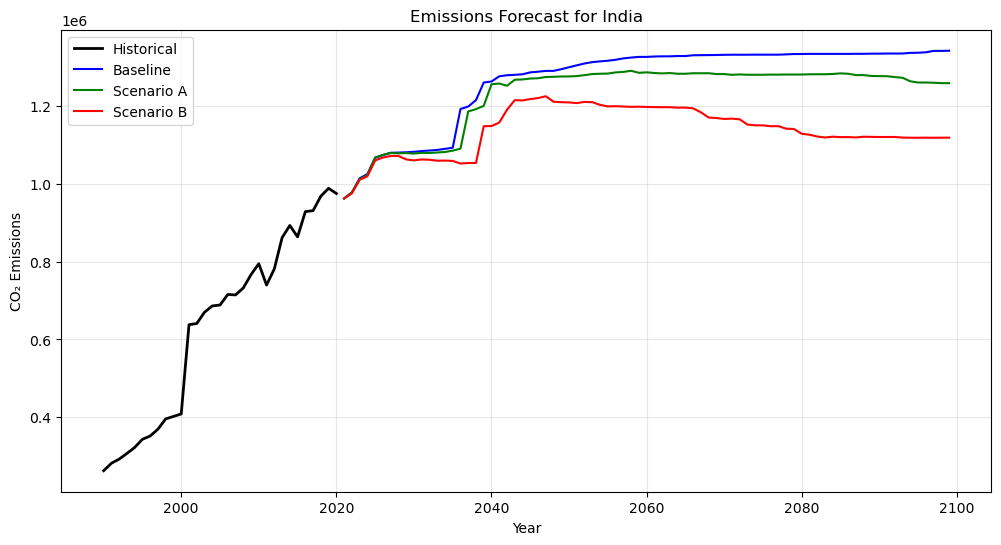

In [171]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load predictions  
pred = pd.read_csv("rf_scenario_predictions.csv")

# 2. Load historical emissions  
hist = pd.read_csv("Agrofood_co2_emission_clean.csv")

def plot_country(country):
    plt.figure(figsize=(12,6))

    # Filter for selected country
    hist_c = hist[hist["Area"] == country]
    pred_c = pred[pred["Area"] == country]

    # Historical
    plt.plot(
        hist_c["Year"], hist_c["total_emission"],
        label="Historical", color="black", linewidth=2
    )

    # Baseline
    base = pred_c[pred_c["scenario"] == "Baseline"]
    plt.plot(base["Year"], base["prediction_raw"],
             label="Baseline", color="blue")

    # Scenario A
    A = pred_c[pred_c["scenario"] == "A"]
    plt.plot(A["Year"], A["prediction_raw"],
             label="Scenario A", color="green")

    # Scenario B
    B = pred_c[pred_c["scenario"] == "B"]
    plt.plot(B["Year"], B["prediction_raw"],
             label="Scenario B", color="red")

    plt.title(f"Emissions Forecast for {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Example:
plot_country("India")


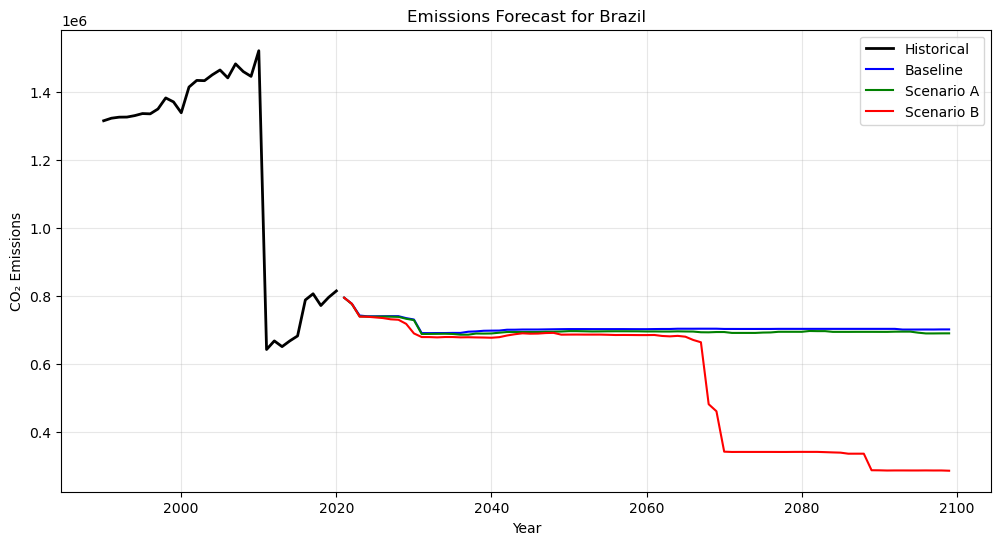

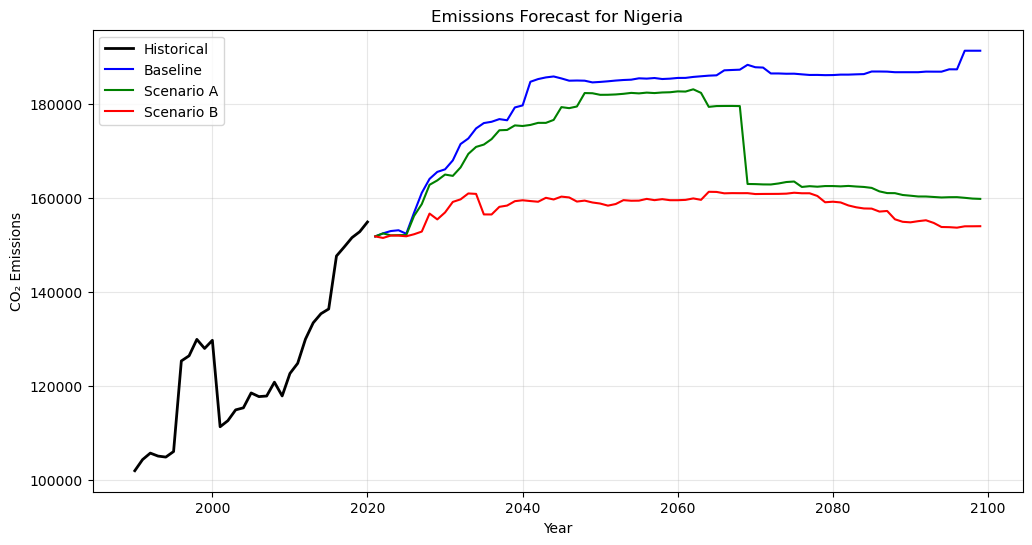

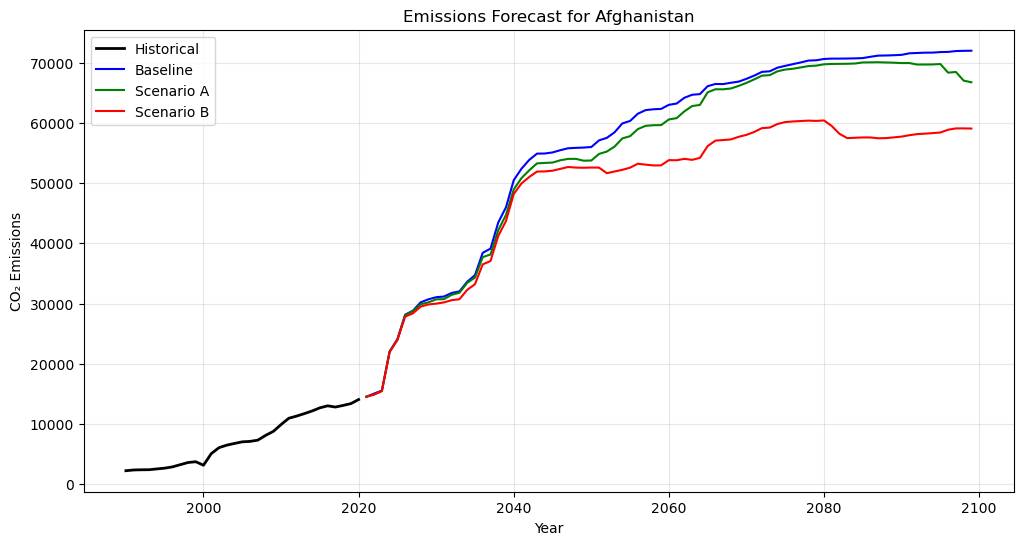

In [175]:
plot_country("Brazil")
plot_country("Nigeria")
plot_country("Afghanistan")


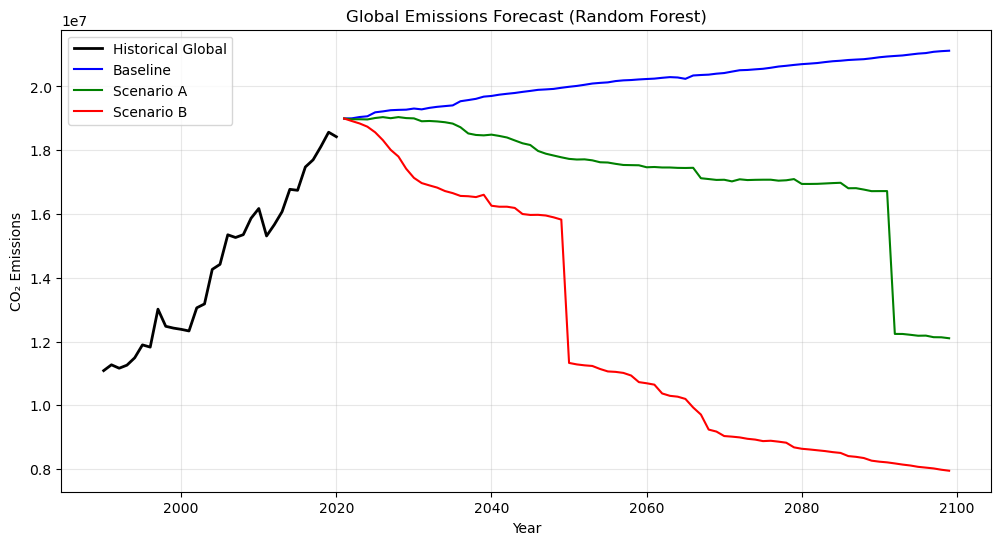

In [172]:
hist_global = hist.groupby("Year")["total_emission"].sum().reset_index()
pred_global = pred.groupby(["Year","scenario"])["prediction_raw"].sum().reset_index()

plt.figure(figsize=(12,6))

# Historical
plt.plot(hist_global["Year"], hist_global["total_emission"], 
         label="Historical Global", color="black", linewidth=2)

# Baseline
plt.plot(pred_global[pred_global["scenario"]=="Baseline"]["Year"],
         pred_global[pred_global["scenario"]=="Baseline"]["prediction_raw"],
         label="Baseline", color="blue")

# Scenario A
plt.plot(pred_global[pred_global["scenario"]=="A"]["Year"],
         pred_global[pred_global["scenario"]=="A"]["prediction_raw"],
         label="Scenario A", color="green")

# Scenario B
plt.plot(pred_global[pred_global["scenario"]=="B"]["Year"],
         pred_global[pred_global["scenario"]=="B"]["prediction_raw"],
         label="Scenario B", color="red")

plt.title("Global Emissions Forecast (Random Forest)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



===== BASELINE MODEL COMPARISON =====

          Model  Test_RMSE   Test_R2
2  RandomForest   0.036371  0.982277
3         Lasso   0.081770  0.910420
1         Ridge   0.120871  0.804267
0       XGBoost   0.134609  0.757244


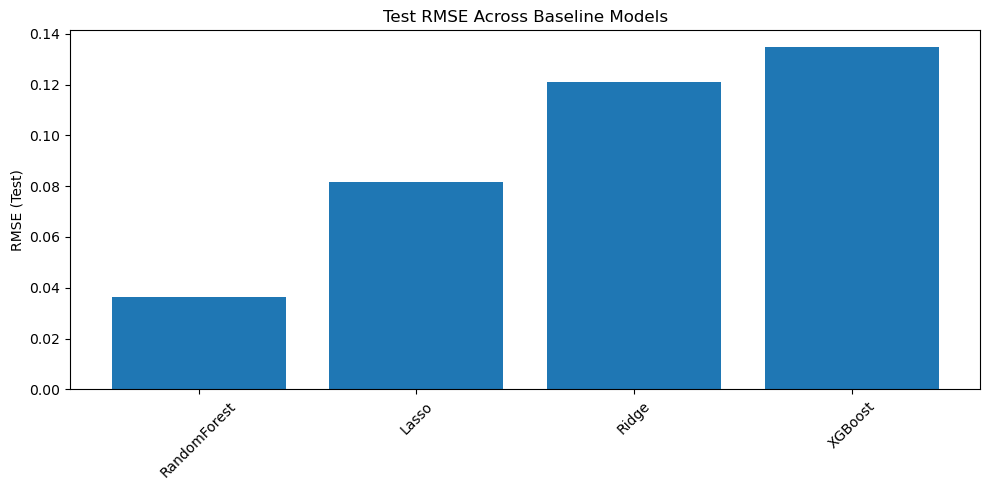

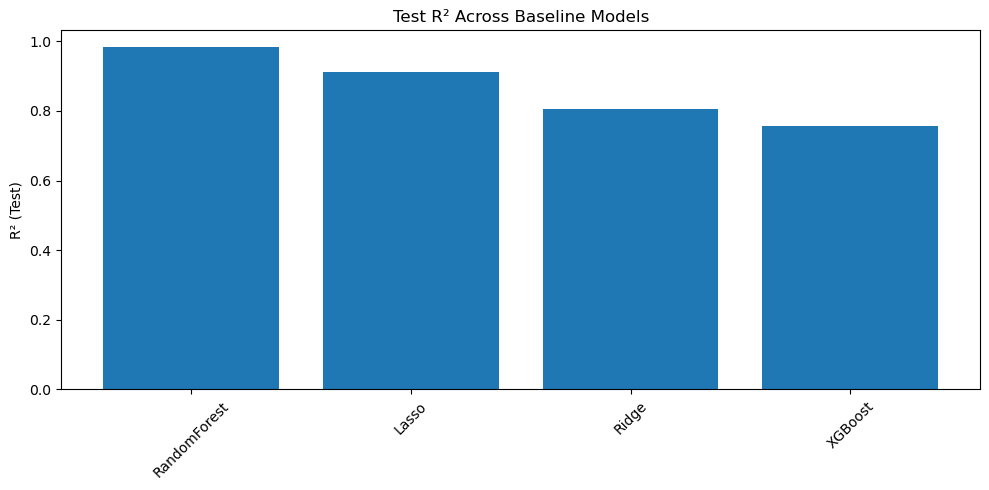

In [188]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. CONNECT TO MLFLOW EXPERIMENT
# ----------------------------------------------------
mlflow.set_tracking_uri("http://127.0.0.1:5000")
exp = mlflow.get_experiment_by_name("Agrofood_Final")

# Fetch all runs
runs_df = mlflow.search_runs(experiment_ids=[exp.experiment_id])

# ----------------------------------------------------
# 2. EXTRACT MODEL METRICS
# ----------------------------------------------------
comparison = []

# Detect all baseline models automatically based on metric names
metric_cols = runs_df.columns

models = set()
for col in metric_cols:
    if "_rmse_test" in col:
        models.add(col.replace("metrics.", "").replace("_rmse_test", ""))

# Build comparison rows
for model in models:
    rmse = runs_df[f"metrics.{model}_rmse_test"].dropna().values[0]
    r2   = runs_df[f"metrics.{model}_r2_test"].dropna().values[0]

    comparison.append({
        "Model": model,
        "Test_RMSE": rmse,
        "Test_R2": r2,
    })

comparison_df = pd.DataFrame(comparison).sort_values("Test_RMSE")
print("\n===== BASELINE MODEL COMPARISON =====\n")
print(comparison_df)

# Optional: save to CSV
comparison_df.to_csv("baseline_model_comparison.csv", index=False)

# ----------------------------------------------------
# 3. PLOT RMSE AND R2
# ----------------------------------------------------
plt.figure(figsize=(10,5))
plt.bar(comparison_df["Model"], comparison_df["Test_RMSE"])
plt.ylabel("RMSE (Test)")
plt.title("Test RMSE Across Baseline Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.bar(comparison_df["Model"], comparison_df["Test_R2"])
plt.ylabel("R² (Test)")
plt.title("Test R² Across Baseline Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [189]:
# ================================================
# MLflow Logging — One Run Per Baseline Model
# ================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Agrofood_Final")

print("\n🚀 Logging each baseline model as SEPARATE MLflow runs...\n")

for name, res in results.items():

    print(f"📦 Starting MLflow run for: {name}")

    with mlflow.start_run(run_name=f"{name}_Baseline_Tuned"):

        # -----------------------------
        # Log general info
        mlflow.log_param("model_name", name)
        mlflow.log_param("train_end_year", TRAIN_END_YEAR)
        mlflow.log_param("target", "log_total_emission_shifted")

        # -----------------------------
        # Log metrics
        mlflow.log_metric("rmse_train", res["rmse_train"])
        mlflow.log_metric("rmse_test",  res["rmse_test"])
        mlflow.log_metric("r2_train",   res["r2_train"])
        mlflow.log_metric("r2_test",    res["r2_test"])

        # -----------------------------
        # Extract model params from pipeline
        model_pipeline = res["model"]
        model_params = model_pipeline.named_steps["model"].get_params()

        # Log ONLY tuned params (cleaner)
        if name in param_grids:
            raw_keys = param_grids[name].keys()
            tuned_keys = [k.split("__")[-1] for k in raw_keys]
            tuned_params = {k: model_params[k] for k in tuned_keys}
        else:
            tuned_params = model_params  # fallback
        
        for p, v in tuned_params.items():
            mlflow.log_param(p, v)

        # -----------------------------
        # Log the full sklearn model
        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            artifact_path="model"
        )

    print(f"✔ Finished logging: {name}\n")

print("\n🎉 All baseline models logged as separate MLflow runs!")



🚀 Logging each baseline model as SEPARATE MLflow runs...

📦 Starting MLflow run for: Ridge


2025/12/01 00:05:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
python(88759) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
2025/12/01 00:05:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/01 00:05:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
python(88771) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


🏃 View run Ridge_Baseline_Tuned at: http://127.0.0.1:5000/#/experiments/933300457519941829/runs/08e0127b53be4ee1acc7c76d2a623461
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/933300457519941829
✔ Finished logging: Ridge

📦 Starting MLflow run for: Lasso


2025/12/01 00:05:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/01 00:05:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Lasso_Baseline_Tuned at: http://127.0.0.1:5000/#/experiments/933300457519941829/runs/713d581afaab486cbed0bca31ddb415b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/933300457519941829
✔ Finished logging: Lasso

📦 Starting MLflow run for: RandomForest


python(88775) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
2025/12/01 00:05:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/01 00:05:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
python(88779) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


🏃 View run RandomForest_Baseline_Tuned at: http://127.0.0.1:5000/#/experiments/933300457519941829/runs/7f7a8cdd3cb14d708000982cefc7024d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/933300457519941829
✔ Finished logging: RandomForest

📦 Starting MLflow run for: XGBoost


2025/12/01 00:05:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run XGBoost_Baseline_Tuned at: http://127.0.0.1:5000/#/experiments/933300457519941829/runs/4fc8e95c04504c759dc891abe95c65a9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/933300457519941829
✔ Finished logging: XGBoost


🎉 All baseline models logged as separate MLflow runs!


--- Ridge ---


/var/folders/1y/b256x0zs517c5bwmlhdp0pgc0000gn/T/ipykernel_73224/3073006645.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='value', y='feature', orient='h', palette='viridis')


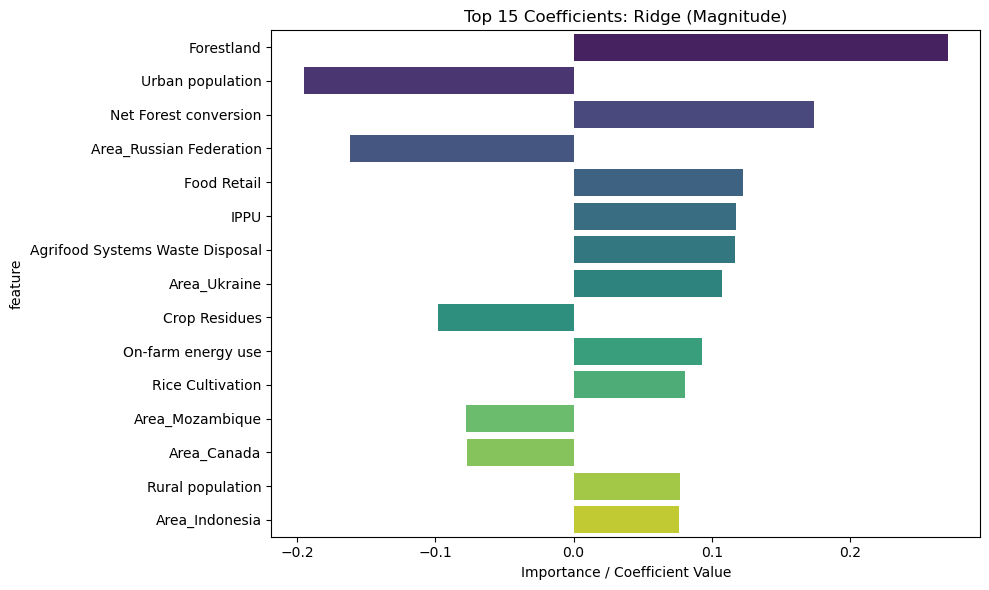

                             feature     value
2                         Forestland  0.270761
24                  Urban population -0.195374
3              Net Forest conversion  0.174179
203          Area_Russian Federation -0.162011
18                       Food Retail  0.122781
13                              IPPU  0.117783
20   Agrifood Systems Waste Disposal  0.116692
247                     Area_Ukraine  0.107691
7                      Crop Residues -0.098118
21                On-farm energy use  0.093178
8                   Rice Cultivation  0.080627
170                  Area_Mozambique -0.077565
65                       Area_Canada -0.077434
23                  Rural population  0.077270
128                   Area_Indonesia  0.076441


--- Lasso ---


/var/folders/1y/b256x0zs517c5bwmlhdp0pgc0000gn/T/ipykernel_73224/3073006645.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='value', y='feature', orient='h', palette='viridis')


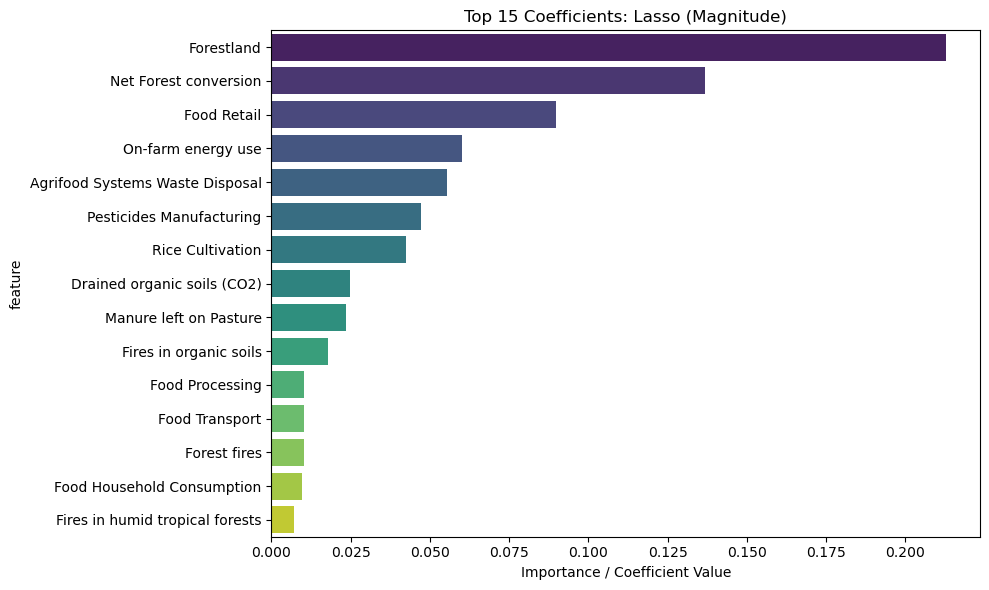

                            feature     value
2                        Forestland  0.212864
3             Net Forest conversion  0.136704
18                      Food Retail  0.089921
21               On-farm energy use  0.060119
20  Agrifood Systems Waste Disposal  0.055268
22         Pesticides Manufacturing  0.047198
8                  Rice Cultivation  0.042591
4       Drained organic soils (CO2)  0.024946
10           Manure left on Pasture  0.023467
5            Fires in organic soils  0.017695
15                  Food Processing  0.010354
17                   Food Transport  0.010236
1                      Forest fires  0.010206
19       Food Household Consumption  0.009762
6   Fires in humid tropical forests  0.007134


--- XGBoost ---


/var/folders/1y/b256x0zs517c5bwmlhdp0pgc0000gn/T/ipykernel_73224/3073006645.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='value', y='feature', orient='h', palette='viridis')


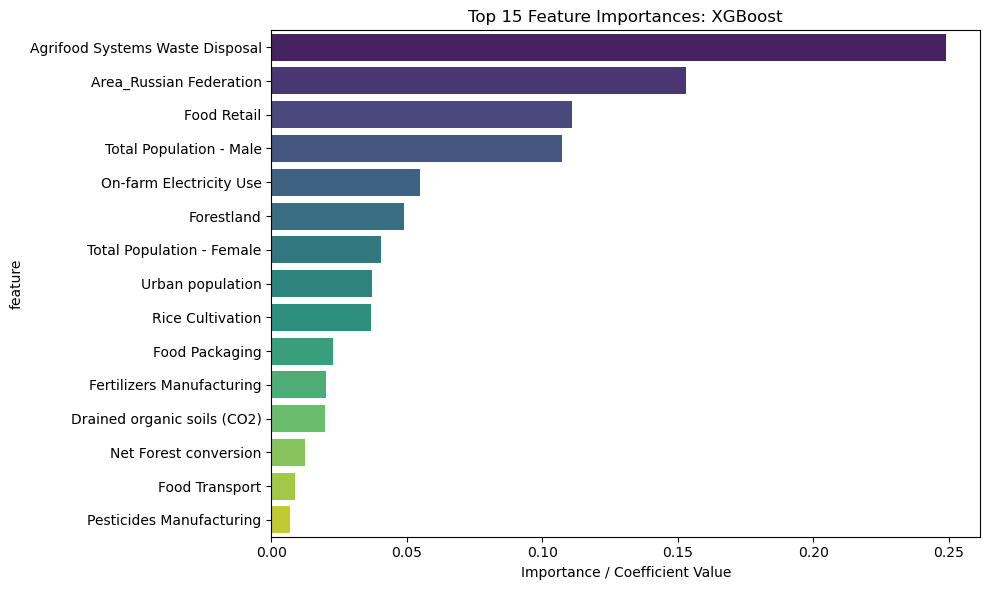

                             feature     value
20   Agrifood Systems Waste Disposal  0.248983
203          Area_Russian Federation  0.153141
18                       Food Retail  0.110721
25           Total Population - Male  0.107265
14           On-farm Electricity Use  0.054949
2                         Forestland  0.048755
26         Total Population - Female  0.040593
24                  Urban population  0.037163
8                   Rice Cultivation  0.036858
16                    Food Packaging  0.022715
12         Fertilizers Manufacturing  0.020229
4        Drained organic soils (CO2)  0.019759
3              Net Forest conversion  0.012546
17                    Food Transport  0.008780
22          Pesticides Manufacturing  0.006855


--- RandomForest ---


/var/folders/1y/b256x0zs517c5bwmlhdp0pgc0000gn/T/ipykernel_73224/3073006645.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='value', y='feature', orient='h', palette='viridis')


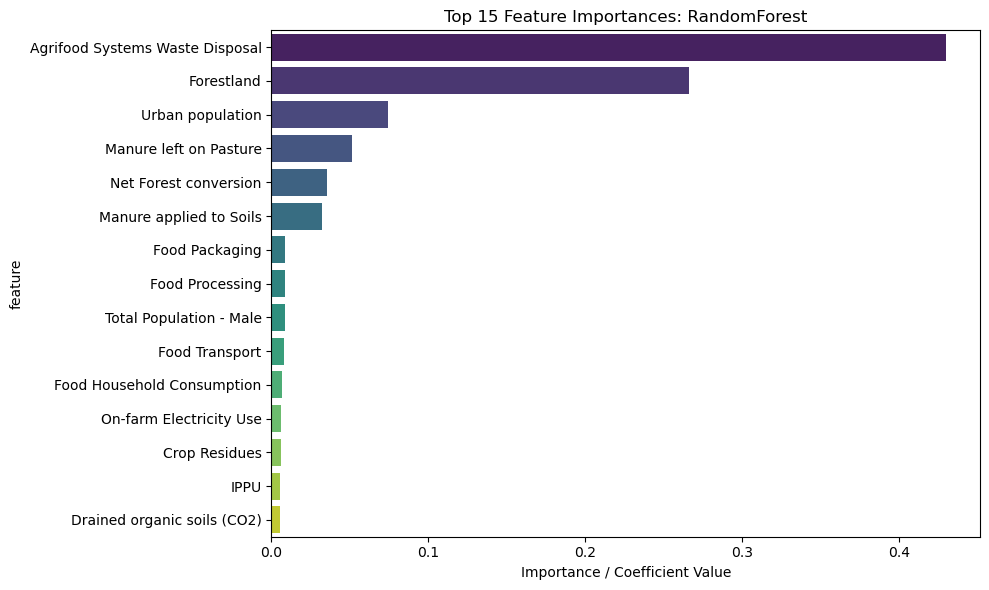

                            feature     value
20  Agrifood Systems Waste Disposal  0.430324
2                        Forestland  0.266255
24                 Urban population  0.074084
10           Manure left on Pasture  0.051502
3             Net Forest conversion  0.035380
9           Manure applied to Soils  0.032448
16                   Food Packaging  0.008789
15                  Food Processing  0.008739
25          Total Population - Male  0.008593
17                   Food Transport  0.008108
19       Food Household Consumption  0.006617
14          On-farm Electricity Use  0.006290
7                     Crop Residues  0.005890
13                             IPPU  0.005712
4       Drained organic soils (CO2)  0.005251




In [190]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def get_feature_names(pipeline, numeric_cols, cat_cols):
    """Extracts feature names from the column transformer within the pipeline."""
    preprocessor = pipeline.named_steps['preprocessor']
    
    # Get categorical feature names after OneHotEncoding
    ohe = preprocessor.named_transformers_['cat']
    ohe_feature_names = list(ohe.get_feature_names_out(cat_cols))
    
    # Combine with numerical columns
    return numeric_cols + ohe_feature_names

def plot_top_features(model_name, results_dict, numeric_cols, cat_cols, top_n=10):
    """Extracts and plots top features for a specific model."""
    
    # Get the pipeline and the actual model
    pipeline = results_dict[model_name]['model']
    model = pipeline.named_steps['model']
    
    # Get all feature names (Num + Encoded Cats)
    feature_names = get_feature_names(pipeline, numeric_cols, cat_cols)
    
    # Extract values based on model type
    if model_name in ["Ridge", "Lasso"]:
        # Linear models use coefficients
        # We take absolute value to see magnitude of impact
        importances = model.coef_
        df_imp = pd.DataFrame({'feature': feature_names, 'value': importances})
        df_imp['abs_value'] = df_imp['value'].abs()
        df_imp = df_imp.sort_values('abs_value', ascending=False).head(top_n)
        title = f"Top {top_n} Coefficients: {model_name} (Magnitude)"
        
    elif model_name in ["RandomForest", "XGBoost"]:
        # Tree models use feature_importances_
        importances = model.feature_importances_
        df_imp = pd.DataFrame({'feature': feature_names, 'value': importances})
        df_imp = df_imp.sort_values('value', ascending=False).head(top_n)
        title = f"Top {top_n} Feature Importances: {model_name}"
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_imp, x='value', y='feature', orient='h', palette='viridis')
    plt.title(title)
    plt.xlabel("Importance / Coefficient Value")
    plt.tight_layout()
    plt.show()
    
    return df_imp

# --- EXECUTE FOR ALL MODELS ---
# Define your original column lists (from your notebook variables)
# Note: Ensure 'categorical_cols' and 'numerical_cols' variables from your previous cells are available
for model_name in ["Ridge", "Lasso", "XGBoost", "RandomForest"]:
    print(f"--- {model_name} ---")
    top_feats = plot_top_features(model_name, results, numerical_cols, categorical_cols, top_n=15)
    print(top_feats[['feature', 'value']])
    print("\n")

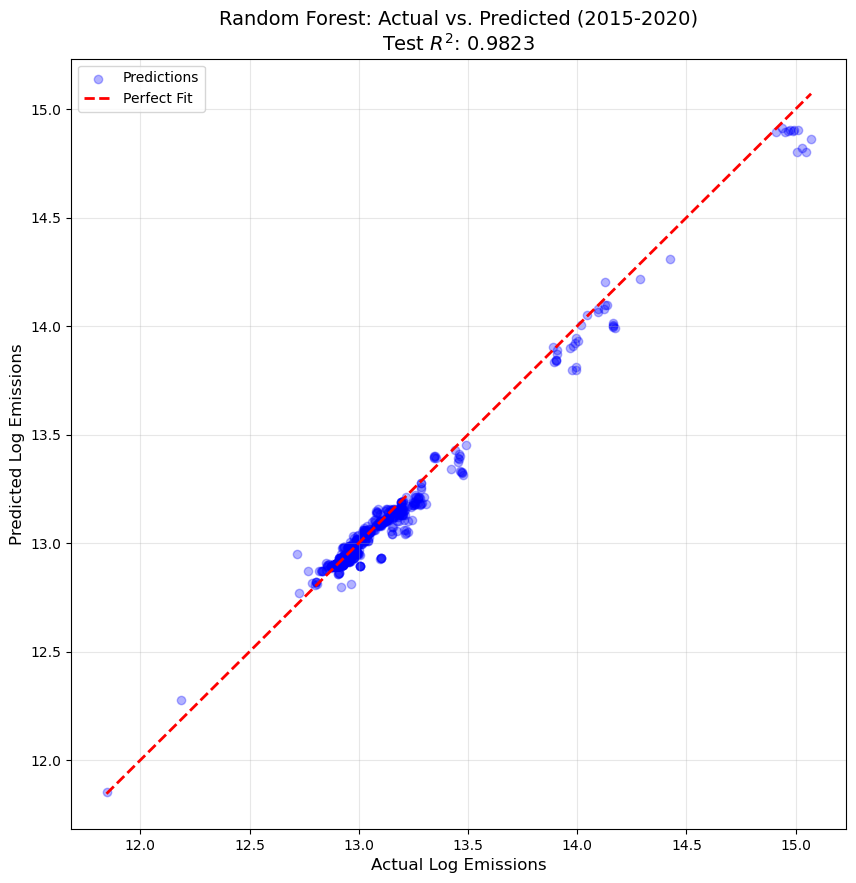

In [191]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 1. Get the trained Random Forest model
rf_pipeline = results["RandomForest"]["model"]

# 2. Make predictions on the Test set (2015-2020)
# Note: y_test and predictions are likely in Log Scale based on your preprocessing
y_pred_rf = rf_pipeline.predict(X_test)

# 3. Calculate R2 for the plot title
r2 = r2_score(y_test, y_pred_rf)

# 4. Plot
plt.figure(figsize=(10, 10))

# Scatter plot of Actual vs Predicted
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue', label='Predictions')

# Perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f"Random Forest: Actual vs. Predicted (2015-2020)\nTest $R^2$: {r2:.4f}", fontsize=14)
plt.xlabel("Actual Log Emissions", fontsize=12)
plt.ylabel("Predicted Log Emissions", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


===== ALL MODEL COMPARISON (BASELINE + LSTM + TFT) =====

          Model  Test_RMSE   Test_R2
0  RandomForest   0.036371  0.982277
5           TFT   0.052835  0.962738
3         Lasso   0.081770  0.910420
2         Ridge   0.120871  0.804267
1       XGBoost   0.134609  0.757244
4          LSTM   0.171900  0.608700


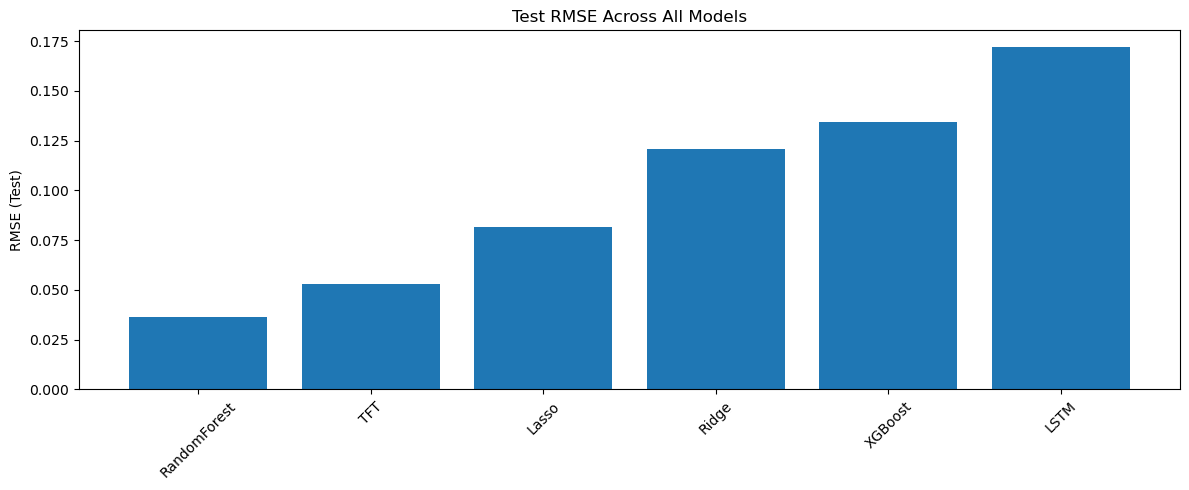

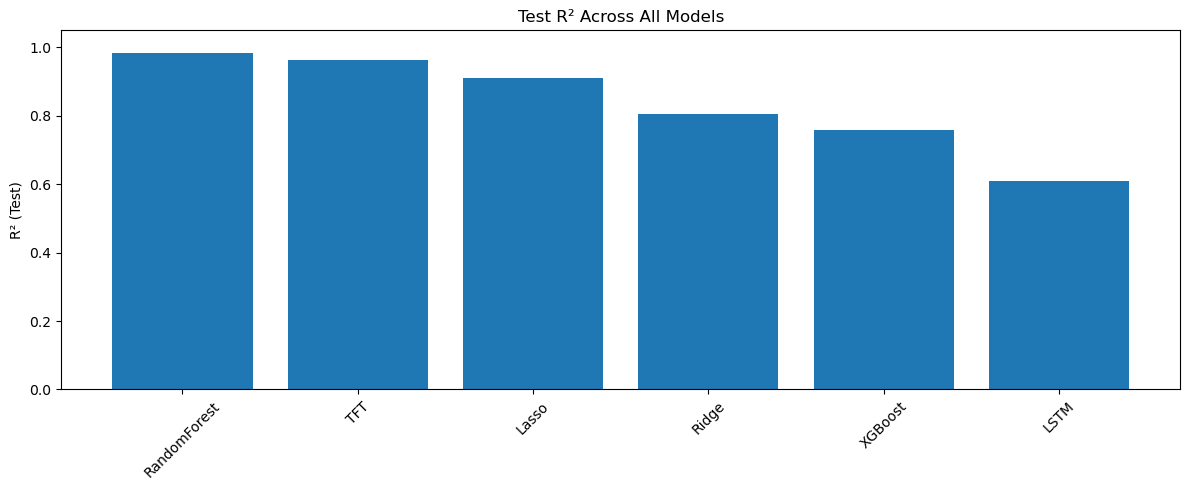

In [192]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. CONNECT TO MLFLOW EXPERIMENT
# ----------------------------------------------------
mlflow.set_tracking_uri("http://127.0.0.1:5000")
exp = mlflow.get_experiment_by_name("Agrofood_Final")

# Fetch all runs
runs_df = mlflow.search_runs(experiment_ids=[exp.experiment_id])

# ----------------------------------------------------
# 2. EXTRACT BASELINE MODEL METRICS
# ----------------------------------------------------
comparison = []

metric_cols = runs_df.columns
models = set()

# Detect baseline model names
for col in metric_cols:
    if "_rmse_test" in col:
        models.add(col.replace("metrics.", "").replace("_rmse_test", ""))

# Build rows from MLflow baseline runs
for model in models:
    rmse = runs_df[f"metrics.{model}_rmse_test"].dropna().values[0]
    r2   = runs_df[f"metrics.{model}_r2_test"].dropna().values[0]
    comparison.append({"Model": model, "Test_RMSE": rmse, "Test_R2": r2})

# ----------------------------------------------------
# 3. ADD HARD-CODED LSTM + TFT METRICS
# ----------------------------------------------------
comparison.append({
    "Model": "LSTM",
    "Test_RMSE": 0.1719,
    "Test_R2": 0.6087
})

comparison.append({
    "Model": "TFT",
    "Test_RMSE": 0.052835285663604736,
    "Test_R2": 0.9627380967140198
})

# ----------------------------------------------------
# 4. CREATE FINAL COMPARISON TABLE
# ----------------------------------------------------
comparison_df = pd.DataFrame(comparison).sort_values("Test_RMSE")
print("\n===== ALL MODEL COMPARISON (BASELINE + LSTM + TFT) =====\n")
print(comparison_df)

comparison_df.to_csv("all_model_comparison.csv", index=False)

# ----------------------------------------------------
# 5. PLOT RMSE AND R2 FOR ALL MODELS
# ----------------------------------------------------
plt.figure(figsize=(12,5))
plt.bar(comparison_df["Model"], comparison_df["Test_RMSE"])
plt.ylabel("RMSE (Test)")
plt.title("Test RMSE Across All Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.bar(comparison_df["Model"], comparison_df["Test_R2"])
plt.ylabel("R² (Test)")
plt.title("Test R² Across All Models")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
